# Actividad Opcional 4 — Análisis climático región Patagónica

## Fuente de datos

**Archivo:** `datasets/smn_historico.csv` (Servicio Meteorológico Nacional)

**Variables disponibles:** estación, provincia, altura, número, código OACI, latitud, longitud, mes, precipitación ≥ 1 mm, humedad, nubosidad, precipitación [mm], temperatura, temperatura máxima, temperatura mínima y velocidad del viento.

**Datos faltantes:** el archivo usa el marcador `S/D` ("sin dato"), que cargaremos como `NaN`.

## Región de estudio: Patagónica

Provincias que componen la región Patagónica:

- NEUQUÉN (`NEUQUEN`)
- RÍO NEGRO (`RIO NEGRO`)
- CHUBUT
- SANTA CRUZ
- TIERRA DEL FUEGO (`TIERRA DEL FUEG`)
- ANTÁRTIDA (`ANTARTIDA`)

> Nota: en el CSV las provincias están en mayúsculas **sin tildes** y truncadas a 16 caracteres (ej.: `TIERRA DEL FUEG`).

In [1]:
# 1. Carga de datos
from pathlib import Path
import pandas as pd
import numpy as np

RAIZ = Path.cwd()
if (RAIZ / "datasets" / "smn_historico.csv").exists() is False:
    RAIZ = RAIZ.parent

df = pd.read_csv(RAIZ / "datasets" / "smn_historico.csv", na_values=["S/D"])

df.head()

,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
0,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Ene,6.7,67.0,3.1,117.5,24.5,28.4,20.8,16.8
1,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Feb,6.0,69.8,3.2,112.3,23.7,27.3,20.2,15.8
2,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Mar,5.9,71.3,3.1,111.8,22.0,25.5,18.8,14.9
3,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Abr,6.6,73.6,3.5,108.3,18.5,22.0,15.3,13.9
4,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,May,5.0,76.4,4.0,83.3,15.2,18.4,12.3,12.9


In [2]:
print("Registros totales:", len(df))
print("\nProvincias disponibles:")
print(sorted(df["provincia"].dropna().unique()))
print("\nTipos de datos:")
print(df.dtypes.astype(str).to_string())

Registros totales: 1176

Provincias disponibles:
['ANTARTIDA', 'BUENOS AIRES', 'CAPITAL FEDERAL', 'CATAMARCA', 'CHACO', 'CHUBUT', 'CORDOBA', 'CORRIENTES', 'ENTRE RIOS', 'FORMOSA', 'JUJUY', 'LA PAMPA', 'LA RIOJA', 'MENDOZA', 'MISIONES', 'NEUQUEN', 'RIO NEGRO', 'SALTA', 'SAN JUAN', 'SAN LUIS', 'SANTA CRUZ', 'SANTA FE', 'SANTIAGO DEL ES', 'TIERRA DEL FUEG', 'TUCUMAN']

Tipos de datos:
estacion         object
provincia        object
altura          float64
numero          float64
NroOACI          object
LAT_decimal     float64
LON_decimal     float64
mes_txt          object
prec_sup_1mm    float64
humedad         float64
nubosidad       float64
prec_mm         float64
temp            float64
temp_max        float64
temp_min        float64
viento          float64


## 2. Filtrado por región Patagónica

In [3]:
# 2. Filtrado por región Patagónica
PATAGONIA = ["NEUQUEN", "RIO NEGRO", "CHUBUT", "SANTA CRUZ", "TIERRA DEL FUEG", "ANTARTIDA"]

pata = df[df["provincia"].isin(PATAGONIA)].copy()
pata = pata.reset_index(drop=True)

print("Registros en la región Patagónica:", len(pata))
print("\nEstaciones por provincia:")
print(pata.groupby("provincia")["estacion"].nunique())
print("\nDistribución de registros por provincia:")
print(pata["provincia"].value_counts())

Registros en la región Patagónica: 276

Estaciones por provincia:
provincia
ANTARTIDA          6
CHUBUT             3
NEUQUEN            1
RIO NEGRO          5
SANTA CRUZ         6
TIERRA DEL FUEG    2
Name: estacion, dtype: int64

Distribución de registros por provincia:
provincia
ANTARTIDA          72
SANTA CRUZ         72
RIO NEGRO          60
CHUBUT             36
TIERRA DEL FUEG    24
NEUQUEN            12
Name: count, dtype: int64


In [4]:
# 3. Caracterización de la muestra
print("Estaciones de la región:")
print(sorted(pata["estacion"].unique()))

meses = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
print("\nMeses cubiertos:", sorted(pata["mes_txt"].unique(), key=lambda m: meses.index(m)))
print("\nRango de latitud:", pata["LAT_decimal"].min(), "a", pata["LAT_decimal"].max())

Estaciones de la región:
['BARILOCHE AERO', 'BASE BELGRANO II', 'BASE CARLINI (EX JUBANY)', 'BASE ESPERANZA', 'BASE MARAMBIO', 'BASE ORCADAS', 'BASE SAN MARTIN', 'COMODORO RIVADAVIA AERO', 'EL BOLSON AERO', 'EL CALAFATE AERO', 'ESQUEL AERO', 'GOBERNADOR GREGORES AERO', 'MAQUINCHAO', 'NEUQUEN AERO', 'PERITO MORENO AERO', 'PUERTO DESEADO AERO', 'RIO GALLEGOS AERO', 'RIO GRANDE B.A.', 'SAN ANTONIO OESTE AERO', 'SAN JULIAN AERO', 'TRELEW AERO', 'USHUAIA AERO', 'VIEDMA AERO']

Meses cubiertos: ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

Rango de latitud: -77.86666666666666 a -38.95


## 3. Medidas de centralidad: media, mediana y moda

Calculamos **media aritmética**, **mediana** y **moda** de las variables climáticas de la muestra.

- **Media:** sensible a valores atípicos; promedio aritmético.
- **Mediana:** valor central; robusta ante valores extremos.
- **Moda:** valor más frecuente; útil para variables discretas (ej.: `prec_sup_1mm`, `nubosidad`).

In [5]:
# 4. Media, mediana y moda de variables climáticas
columnas = ["altura", "prec_sup_1mm", "humedad", "nubosidad", "prec_mm", "temp", "temp_max", "temp_min", "viento"]

print("\n---------- MEDIA ----------")
print(pata[columnas].mean(numeric_only=True).to_string())

print("\n---------- MEDIANA ----------")
print(pata[columnas].median(numeric_only=True).to_string())

print("\n---------- MODA ----------")
print(pata[columnas].mode(numeric_only=True).iloc[0].to_string())


---------- MEDIA ----------
altura          216.173913
prec_sup_1mm      4.372472
humedad          63.644495
nubosidad         4.593796
prec_mm          30.021910
temp              6.001825
temp_max         11.298545
temp_min          0.852075
viento           18.759524

---------- MEDIANA ----------
altura          62.00
prec_sup_1mm     3.60
humedad         63.00
nubosidad        4.40
prec_mm         23.55
temp             6.95
temp_max        12.60
temp_min         1.70
viento          19.50

---------- MODA ----------
altura           7.0
prec_sup_1mm     3.8
humedad         49.9
nubosidad        3.8
prec_mm         10.1
temp             5.2
temp_max        13.1
temp_min        -2.8
viento          20.0


In [6]:
# 4b. Tabla resumen de centralidad
resumen = pd.DataFrame({
    "media": pata[columnas].mean(numeric_only=True),
    "mediana": pata[columnas].median(numeric_only=True),
    "moda": pata[columnas].mode(numeric_only=True).iloc[0],
    "faltantes": pata[columnas].isna().sum(),
})
resumen = resumen.round(2)
resumen

,media,mediana,moda,faltantes
altura,216.17,62.00,7.0,0
prec_sup_1mm,4.37,3.60,3.8,98
humedad,63.64,63.00,49.9,58
nubosidad,4.59,4.40,3.8,2
prec_mm,30.02,23.55,10.1,98
temp,6.00,6.95,5.2,2
temp_max,11.30,12.60,13.1,1
temp_min,0.85,1.70,-2.8,11
viento,18.76,19.50,20.0,108


### Comentarios

- La **moda** se obtiene con `Series.mode()`, que devuelve la primera moda en caso de empate.
- Para variables continuas como `temp` la moda suele aportar poco; la media y la mediana son las medidas más interpretables.
- La **media** de `prec_mm` suele verse arrastrada por días de lluvia intensa; conviene contrastarla con la mediana, que indica el día típico (sin lluvia en gran parte de la región).

# Respuestas del cuestionario — región Patagónica

Metodología replicada de la clase:
- Frecuencias y conteos → `value_counts()` / `nunique()`
- Estadística descriptiva → `describe()`
- Outliers → método del rango intercuartílico (IQR)
- Correlación → Spearman (`scipy.stats.spearmanr`)
- Asociación numérica-categórica → **eta cuadrado** (`f_oneway`)

## Q1. ¿Cuántas estaciones meteorológicas hay en la región?

Cantidad de estaciones distintas en la muestra filtrada.

In [7]:
n_estaciones = pata["estacion"].nunique()
print("Estaciones meteorológicas en la región:", n_estaciones)
print(sorted(pata["estacion"].unique()))

Estaciones meteorológicas en la región: 23
['BARILOCHE AERO', 'BASE BELGRANO II', 'BASE CARLINI (EX JUBANY)', 'BASE ESPERANZA', 'BASE MARAMBIO', 'BASE ORCADAS', 'BASE SAN MARTIN', 'COMODORO RIVADAVIA AERO', 'EL BOLSON AERO', 'EL CALAFATE AERO', 'ESQUEL AERO', 'GOBERNADOR GREGORES AERO', 'MAQUINCHAO', 'NEUQUEN AERO', 'PERITO MORENO AERO', 'PUERTO DESEADO AERO', 'RIO GALLEGOS AERO', 'RIO GRANDE B.A.', 'SAN ANTONIO OESTE AERO', 'SAN JULIAN AERO', 'TRELEW AERO', 'USHUAIA AERO', 'VIEDMA AERO']


## Q2. ¿Cuál es la altura media de las estaciones?

Promedio de la variable `altura` (en metros).

In [8]:
estaciones_unicas = pata.drop_duplicates("estacion")
altura_media = estaciones_unicas["altura"].mean()
print(f"Altura media (sobre {len(estaciones_unicas)} estaciones únicas): {altura_media:.1f} m")

print("Estadística de altura:")
print(pata["altura"].describe().round(2).to_string())

print("Altura por estación:")
print(pata.groupby("estacion")["altura"].first().sort_values().to_string())

Altura media (sobre 23 estaciones únicas): 216.2 m
Estadística de altura:
count    276.00
mean     216.17
std      272.69
min        7.00
25%       20.00
50%       62.00
75%      326.00
max      888.00
Altura por estación:
estacion
BASE SAN MARTIN               7.0
VIEDMA AERO                   7.0
BASE CARLINI (EX JUBANY)     11.0
BASE ORCADAS                 12.0
RIO GALLEGOS AERO            19.0
SAN ANTONIO OESTE AERO       20.0
RIO GRANDE B.A.              22.0
BASE ESPERANZA               24.0
TRELEW AERO                  43.0
COMODORO RIVADAVIA AERO      46.0
USHUAIA AERO                 57.0
SAN JULIAN AERO              62.0
PUERTO DESEADO AERO          80.0
BASE MARAMBIO               198.0
EL CALAFATE AERO            204.0
BASE BELGRANO II            256.0
NEUQUEN AERO                271.0
EL BOLSON AERO              326.0
GOBERNADOR GREGORES AERO    358.0
PERITO MORENO AERO          429.0
ESQUEL AERO                 797.0
BARILOCHE AERO              835.0
MAQUINCHAO          

## Q3. ¿Cuál es la temperatura media (temp) de la región?

In [9]:
temp_media = pata["temp"].mean()
print(f"Temperatura media: {temp_media:.2f} °C")
print(pata["temp"].describe().round(2).to_string())

Temperatura media: 6.00 °C
count    274.00
mean       6.00
std        9.11
min      -20.90
25%        1.00
50%        6.95
75%       13.00
max       24.10


## Q4. ¿Cuál es el desvío estándar de la temperatura (temp)?

In [10]:
temp_std = pata["temp"].std()
print(f"Desvío estándar de temp: {temp_std:.2f} °C")

Desvío estándar de temp: 9.11 °C


## Q5. ¿En qué mes se registra la mayor precipitación media (prec_mm)?

Promedio de `prec_mm` por mes, ordenado cronológicamente.

In [11]:
meses = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]

prec_por_mes = pata.groupby("mes_txt")["prec_mm"].mean().reindex(meses)
print(prec_por_mes.round(2).to_string())

mes_max = prec_por_mes.idxmax()
print(f"\nMes con mayor precipitación media: {mes_max} ({prec_por_mes.max():.1f} mm)")

mes_txt
Ene    21.43
Feb    24.15
Mar    27.04
Abr    33.07
May    39.79
Jun    48.79
Jul    39.90
Ago    34.86
Sep    23.09
Oct    24.96
Nov    21.74
Dic    21.55

Mes con mayor precipitación media: Jun (48.8 mm)


## Q6. ¿Qué provincia tiene la mayor temperatura media?

In [12]:
temp_por_prov = pata.groupby("provincia")["temp"].mean().sort_values(ascending=False)
print(temp_por_prov.round(2).to_string())

print("Provincia más cálida:", temp_por_prov.idxmax(),
      f"({temp_por_prov.max():.2f} °C)")

provincia
NEUQUEN            14.93
CHUBUT             11.84
RIO NEGRO          11.46
SANTA CRUZ          9.00
TIERRA DEL FUEG     5.86
ANTARTIDA          -5.81
Provincia más cálida: NEUQUEN (14.93 °C)


## Q7. ¿En cuáles de estas variables aparecen valores atípicos (outliers)?

Método del rango intercuartílico (IQR): límites en Q1 − 1.5·IQR y Q3 + 1.5·IQR, tal como en la clase.

In [13]:
def contar_outliers(s, etiqueta):
    datos = s.dropna()
    q1, q3 = datos.quantile(.25), datos.quantile(.75)
    iqr = q3 - q1
    bajo, alto = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = ((datos < bajo) | (datos > alto)).sum()
    print(f"{etiqueta:<10} Q1={q1:6.2f} Q3={q3:6.2f} IQR={iqr:5.2f} "
          f"límites=[{bajo:7.2f}, {alto:7.2f}] -> outliers={n}")
    return n

print("Conteo de outliers por variable (IQR):")
n_temp  = contar_outliers(pata["temp"],    "temp")
n_prec  = contar_outliers(pata["prec_mm"], "prec_mm")

if n_temp > 0 and n_prec > 0:
    print("\n=> Aparecen outliers en temperatura y precipitación.")

Conteo de outliers por variable (IQR):
temp       Q1=  1.00 Q3= 13.00 IQR=12.00 límites=[ -17.00,   31.00] -> outliers=5
prec_mm    Q1= 16.50 Q3= 32.10 IQR=15.60 límites=[  -6.90,   55.50] -> outliers=13

=> Aparecen outliers en temperatura y precipitación.


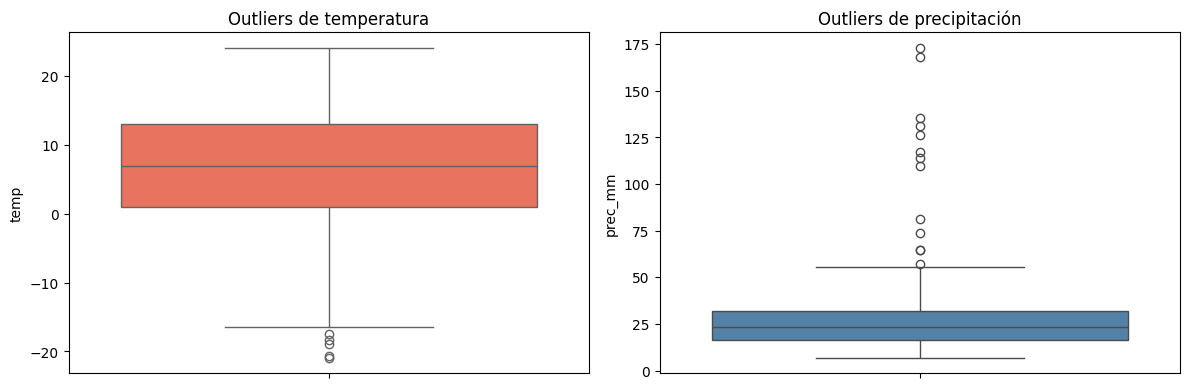

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=pata, y="temp", ax=axes[0], color="tomato")
axes[0].set_title("Outliers de temperatura")
sns.boxplot(data=pata, y="prec_mm", ax=axes[1], color="steelblue")
axes[1].set_title("Outliers de precipitación")
plt.tight_layout()
plt.show()

## Q8. Correlación de Spearman entre altura y temperatura media

Se correlaciona la **altura de cada estación** con su **temperatura media anual**, como en la clase (relación monótona).

In [15]:
from scipy.stats import spearmanr

perfil = (pata.dropna(subset=["temp", "altura"])
            .groupby("estacion")
            .agg(altura=("altura", "first"), temp=("temp", "mean")))

rho, p = spearmanr(perfil["altura"], perfil["temp"])
print(f"n = {len(perfil)} estaciones")
print(f"rho de Spearman = {rho:.3f}")
print(f"p-valor = {p:.4f}")

print("\nTabla altura vs temp media por estación:")
print(perfil.sort_values("altura").round(2).to_string())

if rho < -0.2:
    print("\nConclusión: existe una relación inversa; a mayor altitud"
          " tienden a registrarse temperaturas más bajas.")
elif rho > 0.2:
    print("\nConclusión: ambas variables tienden a crecer juntas.")
else:
    print("\nConclusión: no hay una relación monótona apreciable.")

n = 23 estaciones
rho de Spearman = 0.152
p-valor = 0.4895

Tabla altura vs temp media por estación:
                          altura   temp
estacion                               
BASE SAN MARTIN              7.0  -4.38
VIEDMA AERO                  7.0  14.32
BASE CARLINI (EX JUBANY)    11.0  -1.65
BASE ORCADAS                12.0  -3.10
RIO GALLEGOS AERO           19.0   7.75
SAN ANTONIO OESTE AERO      20.0  14.82
RIO GRANDE B.A.             22.0   5.72
BASE ESPERANZA              24.0  -4.53
TRELEW AERO                 43.0  13.74
COMODORO RIVADAVIA AERO     46.0  13.18
USHUAIA AERO                57.0   6.00
SAN JULIAN AERO             62.0   9.84
PUERTO DESEADO AERO         80.0  10.19
BASE MARAMBIO              198.0  -8.02
EL CALAFATE AERO           204.0   7.43
BASE BELGRANO II           256.0 -13.22
NEUQUEN AERO               271.0  14.93
EL BOLSON AERO             326.0  10.15
GOBERNADOR GREGORES AERO   358.0  10.20
PERITO MORENO AERO         429.0   8.76
ESQUEL AERO        

## Q9. Eta cuadrado (provincia vs precipitación)

Eta cuadrado mide la asociación numérica-categórica (clase 4). Refuerza como **fuerte** si ≥ 0.14.

In [16]:
from scipy.stats import f_oneway

def eta_squared(continuous, categorical):
    mask = continuous.notna() & categorical.notna()
    y, grp = continuous[mask], categorical[mask]
    groups = [g.values for _, g in y.groupby(grp, observed=True)]
    F, p = f_oneway(*groups)
    grand_mean = y.mean()
    ss_total = ((y - grand_mean) ** 2).sum()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    return ss_between / ss_total, p, F

eta2, p_val, F = eta_squared(pata["prec_mm"], pata["provincia"])
print(f"eta cuadrado = {eta2:.4f}   p = {p_val:.2e}   F = {F:.2f}")
print("\nPrecipitación media (prec_mm) por provincia:")
print(pata.groupby("provincia")["prec_mm"].mean().round(2).sort_values(ascending=False).to_string())

if eta2 >= 0.14:
    print("\n=> eta² >= 0.14: asociación fuerte entre provincia y precipitación.")

eta cuadrado = 0.1825   p = 4.53e-07   F = 9.65

Precipitación media (prec_mm) por provincia:
provincia
RIO NEGRO          44.47
TIERRA DEL FUEG    32.64
CHUBUT             26.36
NEUQUEN            17.64
SANTA CRUZ         17.10
ANTARTIDA            NaN

=> eta² >= 0.14: asociación fuerte entre provincia y precipitación.


## Caracterización climática: provincia de NEUQUEN

Resumen climático de la provincia más cálida de la región y comparación estacional (verano: Dic–Ene–Feb; invierno: Jun–Jul–Ago).

In [17]:
provincia_elegida = "NEUQUEN"
df_prov = pata[pata["provincia"] == provincia_elegida].copy()

resumen_prov = pd.DataFrame({
    "Variable": ["Temperatura media", "Precipitación media", "Humedad media",
                  "Nubosidad media", "Viento medio"],
    "Valor": [
        f"{df_prov['temp'].mean():.1f} °C",
        f"{df_prov['prec_mm'].mean():.1f} mm",
        f"{df_prov['humedad'].mean():.1f} %",
        f"{df_prov['nubosidad'].mean():.1f} octas",
        f"{df_prov['viento'].mean():.1f} km/h"
    ]
})
print("Provincia elegida:", provincia_elegida)
display(resumen_prov)

Provincia elegida: NEUQUEN


,Variable,Valor
0,Temperatura media,14.9 °C
1,Precipitación media,17.6 mm
2,Humedad media,53.6 %
3,Nubosidad media,3.4 octas
4,Viento medio,9.8 km/h


In [18]:
verano = df_prov[df_prov["mes_txt"].isin(["Dic", "Ene", "Feb"])]
invierno = df_prov[df_prov["mes_txt"].isin(["Jun", "Jul", "Ago"])]
print("Precipitación media en verano:", round(verano["prec_mm"].mean(), 1), "mm")
print("Precipitación media en invierno:", round(invierno["prec_mm"].mean(), 1), "mm")
print("Temperatura media de enero:",
      round(df_prov.loc[df_prov["mes_txt"].eq("Ene"), "temp"].mean(), 1), "°C")
print("Temperatura media de julio:",
      round(df_prov.loc[df_prov["mes_txt"].eq("Jul"), "temp"].mean(), 1), "°C")

Precipitación media en verano: 12.1 mm
Precipitación media en invierno: 15.0 mm
Temperatura media de enero: 24.1 °C
Temperatura media de julio: 6.0 °C


## Resumen de respuestas

Imprime los resultados finales para completar el cuestionario.

In [19]:
print("1. Cantidad de estaciones:", n_estaciones)
print("2. Altura media:", round(altura_media, 2), "m")
print("3. Temperatura media:", round(temp_media, 2), "°C")
print("4. Desvío estándar de temp:", round(temp_std, 2), "°C")
print("5. Mes de mayor precipitación:", mes_max)
print("6. Provincia de mayor temperatura:", temp_por_prov.idxmax())
print("7. Outliers:", "temperatura y precipitación" if n_temp > 0 and n_prec > 0 else "temperatura" if n_temp > 0 else "precipitación" if n_prec > 0 else "ninguna")
print("8. Spearman altura-temp:", round(rho, 4))
print("9. Eta cuadrado provincia-precipitación:", round(eta2, 4))

1. Cantidad de estaciones: 23
2. Altura media: 216.17 m
3. Temperatura media: 6.0 °C
4. Desvío estándar de temp: 9.11 °C
5. Mes de mayor precipitación: Jun
6. Provincia de mayor temperatura: NEUQUEN
7. Outliers: temperatura y precipitación
8. Spearman altura-temp: 0.1517
9. Eta cuadrado provincia-precipitación: 0.1825
